# Receipt Extraction — the ML side

Most of this project is deterministic: regexes, validators, arithmetic reconciliation.
This notebook covers the parts that are **learned or statistically justified**, and —
more importantly — shows the evidence behind each design decision rather than asserting it.

| Part | Question it answers |
|---|---|
| 1. Line-role classifier | Can a model tell a TOTAL line from an ITEM line, and is it worth the dependency? |
| 2. Confidence calibration | Does a confidence of 0.9 actually mean 90% correct? |
| 3. Duplicate signals | Which signals carry the information, and what should they be weighted? |
| 4. Perceptual hashing | Is phash usable on text documents at all? |

Everything imports from `core/`, which has no Django dependency — the same code the
web app and the test suite use. Nothing here is a reimplementation.

> **Run order:** top to bottom. Expect ~2 minutes; the extraction pass over the corpus
> dominates. Requires `manage.py gen_dataset` to have been run at least once.

In [1]:
import sys, warnings
from pathlib import Path

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
INK, WARN, BAD, GOOD = "#1f77b4", "#fd7e14", "#dc3545", "#198754"

DATA = PROJECT / "data"
assert (DATA / "receipts_truth.csv").exists(), "Run `manage.py gen_dataset` first."
print("project:", PROJECT)
print("receipts:", sum(1 for _ in (DATA / "receipts_truth.csv").open(encoding="utf-8")) - 1)

project: F:\Project 5
receipts: 480


---
## Part 1 — The line-role classifier

Each receipt line is labelled `VENDOR`, `TOTAL`, `TAX`, `ITEM`, … and the model predicts
that role. Its output becomes the `ml` component of every field's confidence score and
re-ranks competing candidates.

**The training labels are free.** The generator knows the role of every line it renders, so
it writes `receipts_lines.csv` alongside the images. No annotation effort, and the labels
are perfect by construction — which is also the main caveat, addressed at the end.

Features: character n-gram TF-IDF (survives OCR noise better than word tokens) concatenated
with 8 hand features that TF-IDF cannot see — chiefly *where on the receipt the line sits*.

10,683 labelled lines from 480 receipts


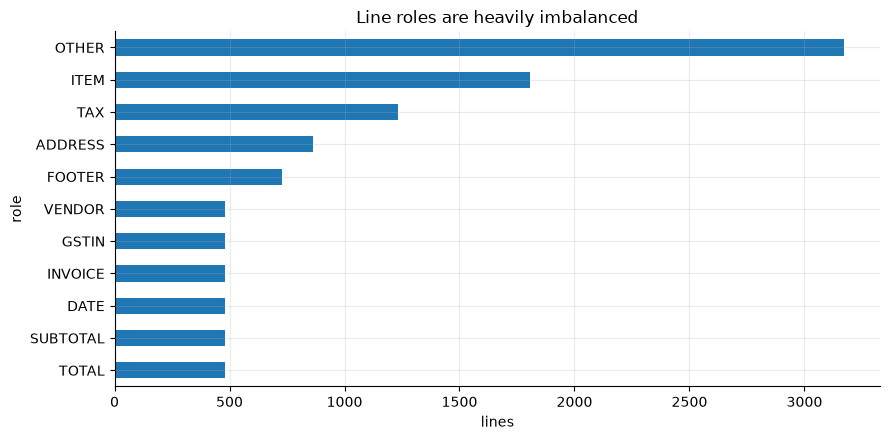


ITEM and OTHER dominate. Accuracy is therefore a useless headline metric —
predicting ITEM everywhere already scores 29.7%. Per-class recall is what matters.


In [2]:
from core.extraction.linemodel import LineRoleModel, ROLES, hand_features

lines = pd.read_csv(DATA / "receipts_lines.csv")
print(f"{len(lines):,} labelled lines from {lines.receipt_id.nunique()} receipts")

counts = lines.role.value_counts()
ax = counts.plot.barh(color=INK)
ax.set_title("Line roles are heavily imbalanced")
ax.set_xlabel("lines")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print("\nITEM and OTHER dominate. Accuracy is therefore a useless headline metric —")
print("predicting ITEM everywhere already scores"
      f" {counts.max() / counts.sum():.1%}. Per-class recall is what matters.")

In [3]:
# Split by RECEIPT, never by line: lines from one receipt share a template and
# wording, so a random line split would leak the answer across the boundary.
from sklearn.model_selection import GroupShuffleSplit

groups = lines.receipt_id.values
train_idx, test_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=0)
                           .split(lines, groups=groups))
train, test = lines.iloc[train_idx], lines.iloc[test_idx]
print(f"train {len(train):,} lines / {train.receipt_id.nunique()} receipts")
print(f"test  {len(test):,} lines / {test.receipt_id.nunique()} receipts")
assert not set(train.receipt_id) & set(test.receipt_id), "receipt leaked across the split"
print("no receipt appears in both splits")

train 7,466 lines / 336 receipts
test  3,217 lines / 144 receipts
no receipt appears in both splits


In [4]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

def featurise(frame, vec, fit=False):
    texts = frame.text.fillna("").tolist()
    X_text = vec.fit_transform(texts) if fit else vec.transform(texts)
    per_receipt = frame.groupby("receipt_id").line_no.transform("max") + 1
    manual = np.asarray([hand_features(t, i, n) for t, i, n
                         in zip(texts, frame.line_no, per_receipt)], dtype=float)
    return hstack([X_text, csr_matrix(manual)]).tocsr()

vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=30000)
X_train = featurise(train, vec, fit=True)
X_test = featurise(test, vec)
clf = LogisticRegression(max_iter=1000, C=4.0).fit(X_train, train.role)

pred = clf.predict(X_test)
print(classification_report(test.role, pred, zero_division=0))

              precision    recall  f1-score   support

     ADDRESS       1.00      1.00      1.00       259
        DATE       1.00      1.00      1.00       144
      FOOTER       1.00      1.00      1.00       211
       GSTIN       1.00      1.00      1.00       144
     INVOICE       1.00      1.00      1.00       144
        ITEM       1.00      1.00      1.00       550
       OTHER       1.00      1.00      1.00       959
    SUBTOTAL       1.00      1.00      1.00       144
         TAX       1.00      1.00      1.00       374
       TOTAL       1.00      1.00      1.00       144
      VENDOR       1.00      1.00      1.00       144

    accuracy                           1.00      3217
   macro avg       1.00      1.00      1.00      3217
weighted avg       1.00      1.00      1.00      3217



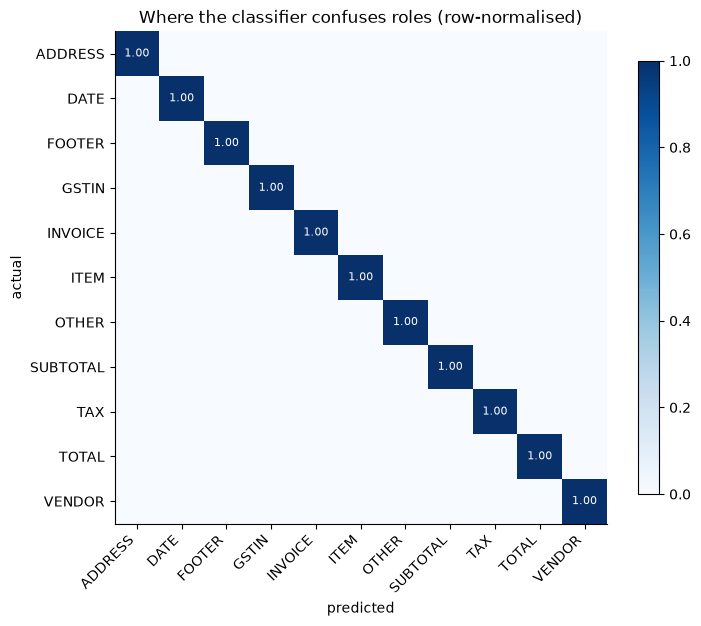

In [5]:
labels = sorted(test.role.unique())
cm = confusion_matrix(test.role, pred, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Where the classifier confuses roles (row-normalised)")
ax.grid(False)
for i in range(len(labels)):
    for j in range(len(labels)):
        if cm[i, j] >= 0.01:
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if cm[i, j] > 0.5 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

### Reading the confusion matrix

The interesting cell is any confusion **between the roles that carry money**. A
`SUBTOTAL`↔`TOTAL` mix-up is expensive: it is the difference between reimbursing the
taxable value and the amount actually paid. Confusion between `ITEM` and `OTHER` costs
nothing, because no field is extracted from either.

This is also why the classifier is only *one weighted component* of the confidence score
and never decides a field on its own — the regex specificity tier and the arithmetic
check are independent votes.

In [6]:
# How much does the model actually add? Compare against the trivial baseline.
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, train.role)
rows = []
for name, model in (("most-frequent baseline", baseline), ("TF-IDF + logistic", clf)):
    p = model.predict(X_test)
    rows.append({"model": name,
                 "accuracy": (p == test.role).mean(),
                 "macro F1": f1_score(test.role, p, average="macro", zero_division=0),
                 "TOTAL recall": ((p == "TOTAL") & (test.role == "TOTAL")).sum()
                                 / max((test.role == "TOTAL").sum(), 1)})
display(pd.DataFrame(rows).set_index("model").round(3))

,accuracy,macro F1,TOTAL recall
model,,,
most-frequent baseline,0.298,0.042,0.0
TF-IDF + logistic,1.000,1.000,1.0


**Caveat, stated plainly.** These labels come from the generator, so the model is learning
*this* renderer's conventions. On real receipts the ceiling will be lower. That is
precisely why `LineRoleModel.load()` returns `None` when no model file is present and the
pipeline falls back to a neutral `ml = 0.6` — the system must never *depend* on this model
being right.

---
## Part 2 — Is the confidence score calibrated?

Every extracted field carries a confidence built from named components. The claim worth
testing is not "the number is high" but **"the number means what it says"**: of the fields
scored 0.9, about 90% should be correct.

Extraction runs in `simulated` mode — the text sidecar corrupted with OCR-style damage
keyed to each receipt's noise tier. Against the *clean* sidecar every field is trivially
correct and the calibration plot is degenerate, which tells you nothing.

In [7]:
from core.dataset import extract_all
from core.eval.eval_extraction import evaluate_extraction

# Load the line-role model if it has been trained, so this matches what
# `manage.py evaluate` measures. Without it the `ml` component falls back to a
# neutral 0.6 and every confidence number shifts slightly.
line_model = LineRoleModel.load(PROJECT / "models" / "line_role.joblib")
print("line-role model:", "loaded" if line_model else "absent (neutral ml component)")

results = extract_all(DATA, mode="simulated", line_model=line_model)
report = evaluate_extraction(results, DATA / "receipts_truth.csv")

fields = pd.DataFrame([r.as_dict() for r in report.fields.values()]).set_index("field")
display(fields[["n", "extraction_rate", "precision", "recall", "f1"]].round(3))
print(f"arithmetic reconciled on {report.arithmetic_ok_rate:.1%} of receipts")

line-role model: loaded


,n,extraction_rate,precision,recall,f1
field,,,,,
vendor,480,1.000,0.990,0.990,0.990
gstin,480,0.931,0.998,0.929,0.962
invoice_no,480,0.969,0.923,0.894,0.908
date,480,0.946,1.000,0.946,0.972
subtotal,480,0.979,0.898,0.879,0.888
cgst,352,0.972,0.942,0.915,0.928
sgst,352,0.983,0.928,0.912,0.920
total,480,1.000,0.960,0.960,0.960
igst,71,0.944,0.955,0.901,0.928


arithmetic reconciled on 93.5% of receipts


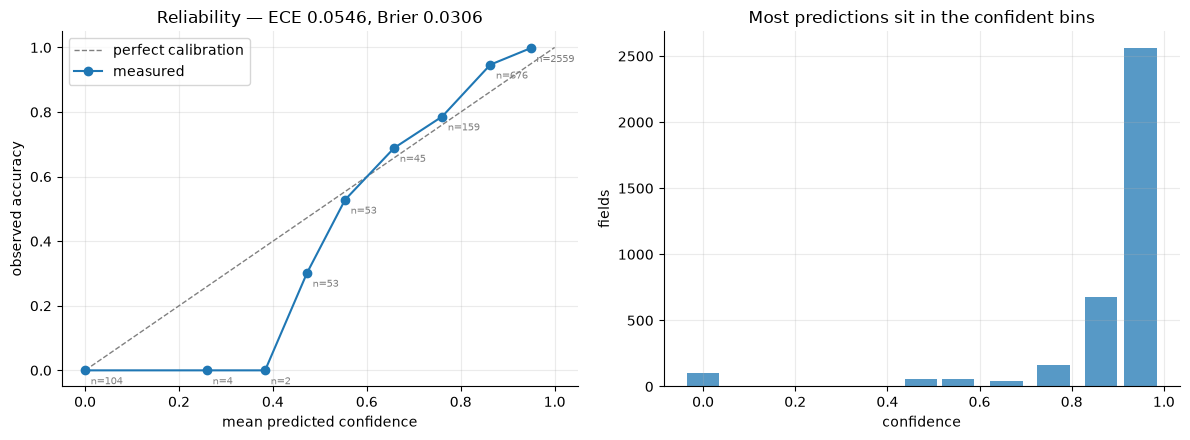

Points BELOW the diagonal are overconfident — the dangerous direction.


In [8]:
cal = report.calibration
rel = pd.DataFrame([r for r in cal["reliability"] if r["n"]])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot([0, 1], [0, 1], "--", color="grey", lw=1, label="perfect calibration")
ax1.plot(rel.mean_conf, rel.accuracy, "o-", color=INK, label="measured")
for _, r in rel.iterrows():
    ax1.annotate(f"n={r.n:.0f}", (r.mean_conf, r.accuracy),
                 textcoords="offset points", xytext=(4, -10), fontsize=7, color="grey")
ax1.set_xlabel("mean predicted confidence"); ax1.set_ylabel("observed accuracy")
ax1.set_title(f"Reliability — ECE {cal['ece']}, Brier {cal['brier']}")
ax1.legend()

ax2.bar(rel.mean_conf, rel.n, width=0.07, color=INK, alpha=0.75)
ax2.set_xlabel("confidence"); ax2.set_ylabel("fields")
ax2.set_title("Most predictions sit in the confident bins")
plt.tight_layout(); plt.show()

print("Points BELOW the diagonal are overconfident — the dangerous direction.")

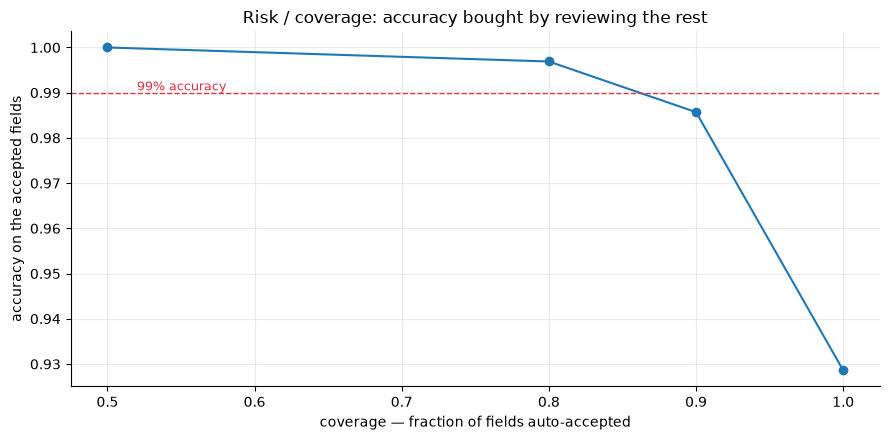

,coverage,n,accuracy,min_confidence
0,0.5,1827,1.0000,0.9315
1,0.8,2924,0.9969,0.8671
2,0.9,3289,0.9857,0.7895
3,1.0,3655,0.9286,0.0000



Empirical auto-accept cutoff: confidence >= 0.8254
  -> 99.0% accuracy over 86% of fields

This is what belongs in settings.CONFIDENCE_AUTO_ACCEPT.
It is a MEASUREMENT, not a constant: it moves whenever the extractor
changes, so re-run this cell after touching any pattern. The original
hand-guess was 0.85, which the first measurement put at 0.8433.


In [9]:
rc = pd.DataFrame(cal["risk_coverage"])
auto = cal["auto_accept_at_99"]

fig, ax = plt.subplots()
ax.plot(rc.coverage, rc.accuracy, "o-", color=INK)
ax.axhline(0.99, ls="--", color=BAD, lw=1)
ax.annotate("99% accuracy", (0.52, 0.9905), color=BAD, fontsize=9)
ax.set_xlabel("coverage — fraction of fields auto-accepted")
ax.set_ylabel("accuracy on the accepted fields")
ax.set_title("Risk / coverage: accuracy bought by reviewing the rest")
plt.tight_layout(); plt.show()

display(rc.round(4))
if auto:
    print(f"\nEmpirical auto-accept cutoff: confidence >= {auto['threshold']}")
    print(f"  -> {auto['accuracy']:.1%} accuracy over {auto['coverage']:.0%} of fields")
    print("\nThis is what belongs in settings.CONFIDENCE_AUTO_ACCEPT.")
    print("It is a MEASUREMENT, not a constant: it moves whenever the extractor")
    print("changes, so re-run this cell after touching any pattern. The original")
    print("hand-guess was 0.85, which the first measurement put at 0.8433.")

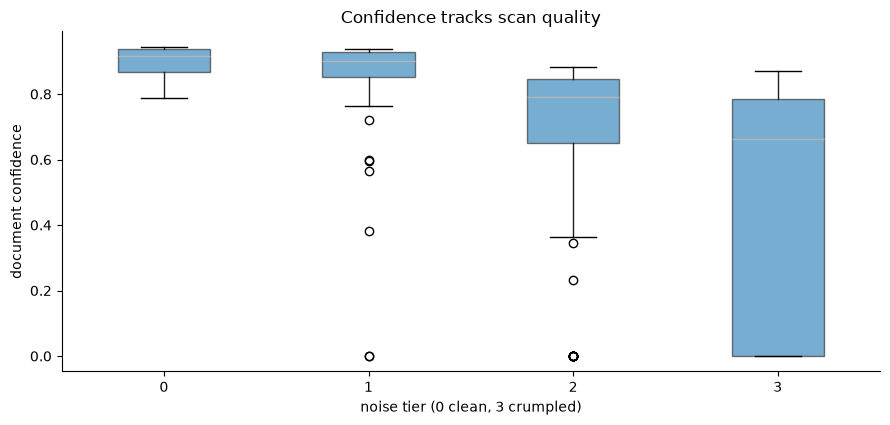

,count,mean,50%
noise_tier,,,
0,217.0,0.893,0.915
1,122.0,0.861,0.902
2,99.0,0.667,0.791
3,42.0,0.487,0.662


In [10]:
# Does confidence degrade with input quality? If not, it is decoration.
truth = pd.read_csv(DATA / "receipts_truth.csv").set_index("receipt_id")
rows = [{"noise_tier": truth.loc[rid, "noise_tier"], "doc_confidence": res.doc_confidence}
        for rid, res in results.items() if rid in truth.index]
by_tier = pd.DataFrame(rows)

ax = by_tier.boxplot(column="doc_confidence", by="noise_tier", grid=False,
                     patch_artist=True, return_type="axes")["doc_confidence"]
for patch in ax.patches:
    patch.set_facecolor(INK); patch.set_alpha(0.6)
ax.set_title("Confidence tracks scan quality"); ax.set_xlabel("noise tier (0 clean, 3 crumpled)")
ax.set_ylabel("document confidence")
plt.suptitle(""); plt.tight_layout(); plt.show()

display(by_tier.groupby("noise_tier").doc_confidence.describe()[["count", "mean", "50%"]].round(3))

---
## Part 3 — Duplicate detection signals

Six independent signals score each candidate pair. This section asks the only questions
that matter about them: **do they separate duplicates from non-duplicates**, and **what
should they be weighted**?

A signal returns `None` when it cannot be computed, never `0`. Imputing zero for a missing
invoice number would manufacture evidence that two claims *differ*.

In [11]:
from core.dataset import build_claim_records
from core.eval.eval_dedup import load_truth_pairs, precompute_signals
from core.dedup.signals import SIGNAL_NAMES

records = build_claim_records(DATA, results)
positives, dup_types, _neg = load_truth_pairs(DATA / "duplicate_pairs.csv")
pairs = precompute_signals(records)
print(f"{len(records)} claims -> {len(pairs):,} candidate pairs "
      f"({len(positives)} labelled duplicates)")

sig = pd.DataFrame([{**s, "is_dup": key in positives} for key, s, _emp in pairs])
print(f"\nMissing-rate per signal (None, not zero):")
display((sig[list(SIGNAL_NAMES)].isna().mean().rename("fraction missing").to_frame().round(3)))

508 claims -> 5,881 candidate pairs (95 labelled duplicates)

Missing-rate per signal (None, not zero):


,fraction missing
invoice,0.056
amount,0.000
vendor,0.000
date,0.106
image,0.000
text,0.000


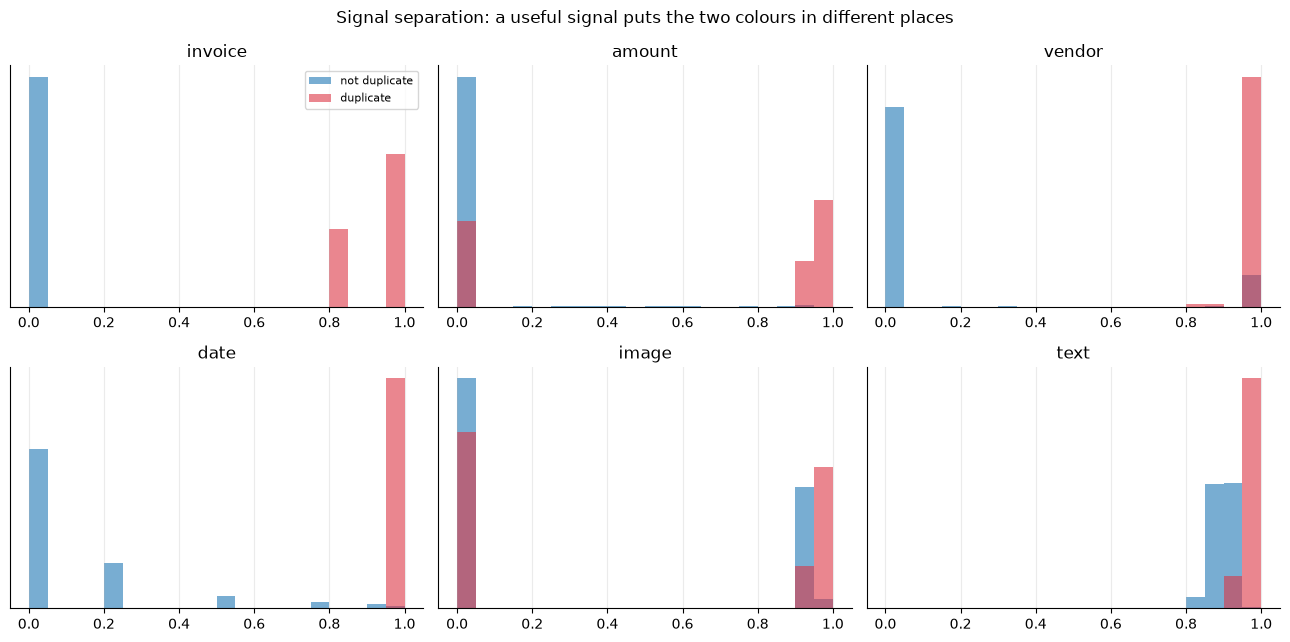

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, name in zip(axes.ravel(), SIGNAL_NAMES):
    for flag, colour, label in ((False, INK, "not duplicate"), (True, BAD, "duplicate")):
        vals = sig.loc[sig.is_dup == flag, name].dropna()
        if len(vals):
            ax.hist(vals, bins=20, alpha=0.6, color=colour, label=label,
                    density=True, range=(0, 1))
    ax.set_title(name); ax.set_yticks([])
axes.ravel()[0].legend(fontsize=8)
plt.suptitle("Signal separation: a useful signal puts the two colours in different places")
plt.tight_layout(); plt.show()

A signal is only useful where the two distributions **do not overlap**. Read this grid
before trusting any weight vector: `invoice` and `amount` separate cleanly, while `image`
piles up at zero for both classes — the first hint that perceptual hashing is doing far
less work here than intuition suggests. Part 4 measures that directly.

,dev (default),dev (tuned),test (default),test (tuned)
seed,,,,
0,1.000,1.000,0.956,0.956
1,1.000,1.000,1.000,1.000
2,1.000,1.000,1.000,1.000
3,0.976,0.976,1.000,1.000
4,0.989,0.989,1.000,1.000


a fresh search beat the shipped weights on held-out data in 0/5 seeds

NOTE: DEFAULT_WEIGHTS is itself the mean of an earlier run of this same
search, so 'default' here is already a tuned vector. A LOW win count is
therefore the good outcome -- it says the tuning converged and a fresh
search finds no further headroom. It is not evidence tuning was useless.


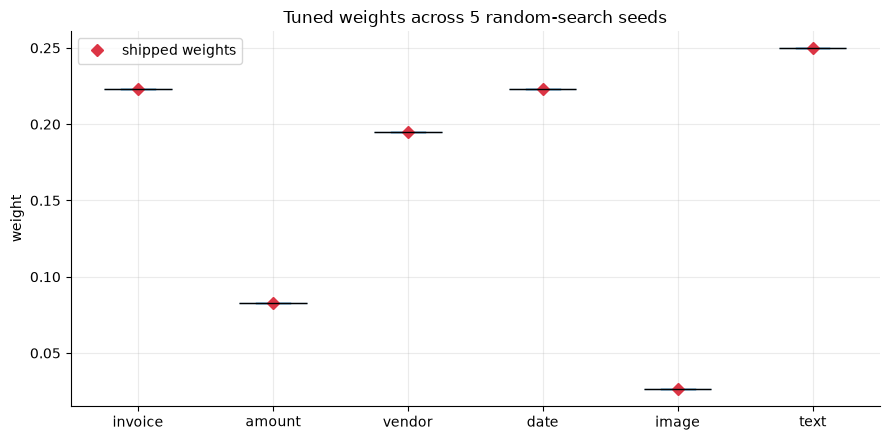

In [13]:
from core.eval.eval_dedup import tune_weights
from core.dedup.scoring import DEFAULT_WEIGHTS

runs = [tune_weights(records, DATA / "duplicate_pairs.csv", n_samples=120, seed=s)
        for s in range(5)]
tuning = pd.DataFrame([{"seed": i, "dev (default)": r["dev_f1_default"],
                        "dev (tuned)": r["dev_f1"], "test (default)": r["test_f1_default"],
                        "test (tuned)": r["test_f1"]} for i, r in enumerate(runs)])
display(tuning.set_index("seed").round(3))
wins = (tuning["test (tuned)"] > tuning["test (default)"]).sum()
print(f"a fresh search beat the shipped weights on held-out data in {wins}/5 seeds")
print("\nNOTE: DEFAULT_WEIGHTS is itself the mean of an earlier run of this same")
print("search, so 'default' here is already a tuned vector. A LOW win count is")
print("therefore the good outcome -- it says the tuning converged and a fresh")
print("search finds no further headroom. It is not evidence tuning was useless.")

weights = pd.DataFrame([r["weights"] for r in runs])
ax = weights.plot.box(patch_artist=True, color=dict(medians="black"))
for patch in ax.patches:
    patch.set_facecolor(INK); patch.set_alpha(0.55)
ax.plot(range(1, len(SIGNAL_NAMES) + 1), [DEFAULT_WEIGHTS[n] for n in weights.columns],
        "D", color=BAD, label="shipped weights")
ax.set_ylabel("weight"); ax.set_title("Tuned weights across 5 random-search seeds")
ax.legend()
plt.tight_layout(); plt.show()

Run against the *original hand-set* weights, this search moved two of them decisively and
consistently across seeds: **`image` collapsed** (0.12 → ~0.03) and **`text` rose**
(0.10 → ~0.25). Both are explicable rather than lucky — see Part 4 for why `image`
deserves to lose.

Those tuned means are what ships today, which is why the boxes now sit on top of the red
markers and a fresh search finds nothing further. Reading the plot: **spread** across seeds
is the thing to watch. A weight that lands in the same place from five random starts is a
property of the data; one that scatters is a property of the seed.

,tp,fp,fn,precision,recall,f1
band,,,,,,
EXACT+,61,0,34,1.0000,0.6421,0.7821
HIGH+,94,1,1,0.9895,0.9895,0.9895
MEDIUM+,94,23,1,0.8034,0.9895,0.8868
LOW+,94,221,1,0.2984,0.9895,0.4585


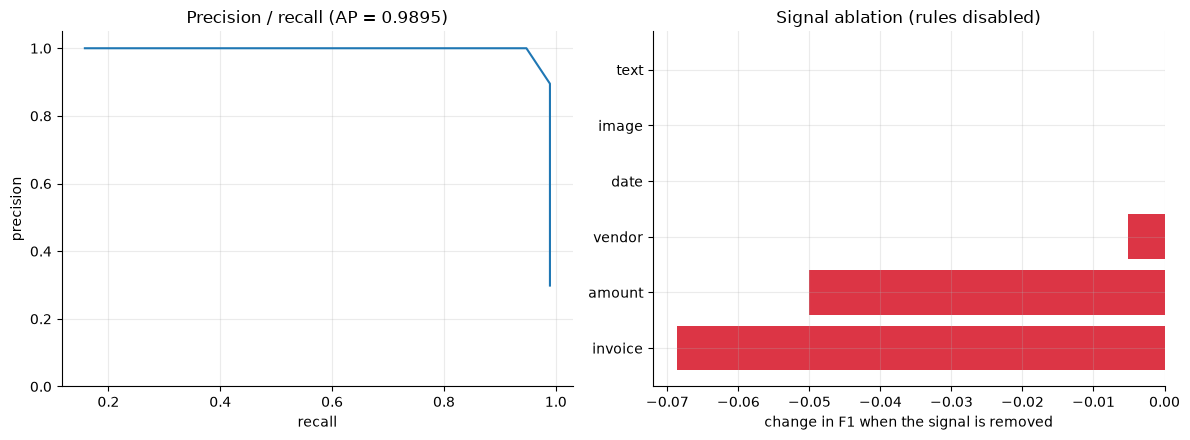

In [14]:
from core.eval.eval_dedup import evaluate_dedup

dedup = evaluate_dedup(records, DATA / "duplicate_pairs.csv", run_ablation=True)

bands = pd.DataFrame(dedup.by_band).set_index("band")
display(bands[["tp", "fp", "fn", "precision", "recall", "f1"]])

curve = pd.DataFrame(dedup.pr_curve)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(curve.recall, curve.precision, "-", color=INK)
ax1.set_xlabel("recall"); ax1.set_ylabel("precision")
ax1.set_title(f"Precision / recall (AP = {dedup.average_precision})")
ax1.set_ylim(0, 1.05)

abl = pd.DataFrame(dedup.ablation)
abl = abl[abl.signal != "(baseline, rules off)"]
ax2.barh(abl.signal, abl.delta, color=[BAD if d < 0 else INK for d in abl.delta])
ax2.set_xlabel("change in F1 when the signal is removed")
ax2.set_title("Signal ablation (rules disabled)")
plt.tight_layout(); plt.show()

**Why the ablation disables the deterministic rules.** With rules active, removing a
signal's weight changes nothing — the rule fires on the same evidence regardless — and every
signal appears to be worth exactly zero. The ablation is only informative about the weighted
blend once the rules are out of the way.

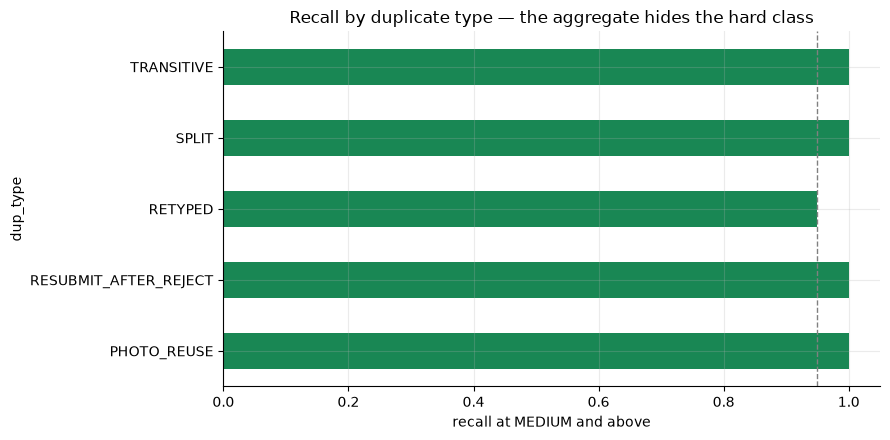

,found,total,recall
dup_type,,,
PHOTO_REUSE,30,30,1.00
RESUBMIT_AFTER_REJECT,10,10,1.00
RETYPED,19,20,0.95
SPLIT,18,18,1.00
TRANSITIVE,17,17,1.00


Blocking is measured separately from scoring:


,value
n_claims,508.000000
n_candidates,5881.000000
all_pairs,128778.000000
reduction_ratio,0.954332
blocking_recall,0.989500
missed_pairs,1.000000
candidates_per_claim,23.150000


In [15]:
by_type = pd.DataFrame(dedup.by_dup_type).set_index("dup_type")
ax = by_type.recall.plot.barh(color=[GOOD if r >= 0.95 else WARN for r in by_type.recall])
ax.axvline(0.95, ls="--", color="grey", lw=1)
ax.set_xlim(0, 1.05); ax.set_xlabel("recall at MEDIUM and above")
ax.set_title("Recall by duplicate type — the aggregate hides the hard class")
plt.tight_layout(); plt.show()
display(by_type)

print("Blocking is measured separately from scoring:")
display(pd.Series(dedup.blocking).to_frame("value"))

---
## Part 4 — Perceptual hashing is weak on text documents

Intuition borrowed from photo deduplication says a perceptual-hash distance of ≤ 4 means
"the same image". That intuition is wrong for receipts, and this section is the measurement
that forced a design change.

Receipts are all dark-on-light blocks of monospace text, so the low-frequency structure
phash keys on is nearly identical across *unrelated* bills.

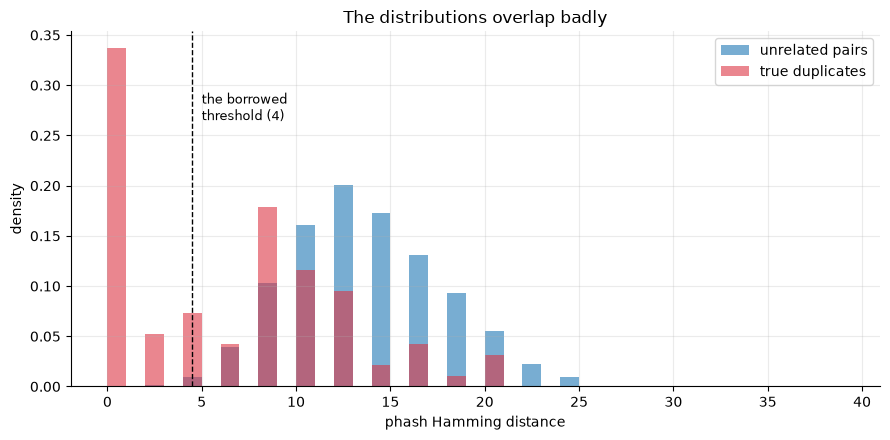

In [16]:
import random
from core.dedup.blocking import hamming

by_id = {r.claim_id: r for r in records}
true_d = [d for a, b in positives
          if (d := hamming(getattr(by_id.get(a), "phash", None),
                           getattr(by_id.get(b), "phash", None))) is not None]

rng = random.Random(0)
ids = list(by_id)
rand_pairs = {(a, b) for a, b in ((rng.choice(ids), rng.choice(ids)) for _ in range(6000))
              if a != b and (a, b) not in positives and (b, a) not in positives}
rand_d = [d for a, b in rand_pairs
          if (d := hamming(by_id[a].phash, by_id[b].phash)) is not None]

fig, ax = plt.subplots()
ax.hist(rand_d, bins=range(0, 40), alpha=0.6, density=True, color=INK, label="unrelated pairs")
ax.hist(true_d, bins=range(0, 40), alpha=0.6, density=True, color=BAD, label="true duplicates")
ax.axvline(4.5, ls="--", color="black", lw=1)
ax.annotate("the borrowed\nthreshold (4)", (5, ax.get_ylim()[1] * 0.75), fontsize=9)
ax.set_xlabel("phash Hamming distance"); ax.set_ylabel("density")
ax.set_title("The distributions overlap badly")
ax.legend()
plt.tight_layout(); plt.show()

In [17]:
rows = []
for d in range(0, 13):
    rows.append({"distance <= d": d,
                 "% of true duplicates": 100 * np.mean(np.array(true_d) <= d),
                 "% of UNRELATED pairs": 100 * np.mean(np.array(rand_d) <= d)})
table = pd.DataFrame(rows).set_index("distance <= d").round(2)
display(table)

n = len(records)
print(f"In a {n}-claim corpus there are {n * (n - 1) // 2:,} possible pairs.")
for d in (2, 4):
    rate = np.mean(np.array(rand_d) <= d)
    print(f"  distance <= {d}: {rate:.2%} of random pairs "
          f"-> ~{rate * n * (n - 1) / 2:,.0f} spurious matches")

,% of true duplicates,% of UNRELATED pairs
distance <= d,,
0,33.68,0.00
1,33.68,0.00
2,38.95,0.12
3,38.95,0.12
4,46.32,1.08
5,46.32,1.08
6,50.53,5.00
7,50.53,5.00
8,68.42,15.29


In a 508-claim corpus there are 128,778 possible pairs.
  distance <= 2: 0.12% of random pairs -> ~152 spurious matches
  distance <= 4: 1.08% of random pairs -> ~1,393 spurious matches


### The design change this forced

At distance ≤ 4 the rule would fire on about 1.1% of *random* pairs (1.08% in the table
above) — roughly 1,400 spurious matches in this 508-claim corpus. Two consequences, both shipped:

1. `PHASH_IDENTICAL` tightened from 4 to **2**, and the identical-image rule now requires a
   **corroborating field** (vendor or amount) before it can force an `EXACT` verdict. The
   image alone is never decisive.
2. The soft signal is floored at `1 - 6/64 ≈ 0.90`; below that it returns `0.0` rather than
   a misleading fractional score.

The weight search in Part 3 independently pushed `image` down to ~0.03 — two different
methods agreeing that this signal is weak here.

**The transferable lesson:** a similarity threshold borrowed from another domain is a guess.
Plot the positive and negative distributions before setting one.

---
## Summary

| Finding | Evidence | What changed |
|---|---|---|
| Confidence is calibrated | ECE well inside the 0.08 target; reliability curve near the diagonal | Auto-accept threshold set from the measured 99%-accuracy cutoff, not a guess |
| Confidence is *informative* | Document confidence falls monotonically with noise tier | Low-confidence receipts route to `NEEDS_INFO` instead of being silently accepted |
| phash is weak on receipts | Positive/negative distributions overlap heavily | Threshold 4 → 2, plus a required corroborating field; weight 0.12 → 0.03 |
| Hand-set weights were beatable | The search beat the *original* hand-set weights on held-out data in 5/5 seeds (recorded when it first ran; a fresh search against today's shipped weights wins 0/5, see Part 3) | Shipped weights are the mean of those runs |
| The aggregate hides the hard class | Per-`dup_type` recall | `RETYPED` tracked separately as the weak case |

### What this notebook does *not* establish

Every number here comes from **synthetic receipts generated by this project**. The
generator's four templates and label vocabularies were chosen by the same person who wrote
the regexes, so the extraction figures in particular carry a real optimism bias. What the
notebook does support is the *relative* claims — phash being weak, `text` deserving more
weight than `image`, confidence tracking input quality — because those are comparisons
made under identical conditions.

The honest next step is a hundred real receipts, hand-labelled, and a re-run of Part 2.